In [22]:
all = [var for var in globals() if var[0] != "_"]
for var in all:
    del globals()[var]

del var, all
# This script clears all global variables except those starting with an underscore.

In [ ]:
import jax
import jax.numpy as jnp
from jax import lax

@jax.tree_util.register_pytree_node_class
class HeatEquation2D_JAX:
    def __init__(self, x_size, y_size, height, n_x, n_y, k=149.0, rho=2323.0, cp=704.611, CFL=0.1):
        ## MESHING variables
        self.n_x = n_x
        self.n_y = n_y        
        # Physical locations
        x_axis = jnp.linspace(0, x_size, n_x)
        y_axis = jnp.linspace(0, y_size, n_y)
        self.X, self.Y = jnp.meshgrid(x_axis, y_axis, indexing='ij')
        self.dx = x_axis[1] - x_axis[0]
        self.dy = y_axis[1] - y_axis[0]
        # Material Properties
        self.k = k
        self.rho = rho
        self.cp = cp
        self.thermal_alpha = k / (rho * cp)
        self.height = height
        ## Temporal Properties
        self.CFL = CFL
        self.dt = CFL * (self.dx * self.dy) / self.thermal_alpha
        ## External Fluid Properties
        self.ext_k = 0.02772 # 외부 공기 열전도도
        self.ext_Pr = 0.7215 # 외부 공기 프란틀 수
        self.ext_nu = 1.506e-5 # 외부 공기 운동 점도
        self.ext_T = 273.0 + 20.0 # 외부 온도

    def tree_flatten(self):
        children = () 
        aux_data = {k: v for k, v in self.__dict__.items()}
        return (children, aux_data)

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        obj = cls.__new__(cls)
        for k, v in aux_data.items():
            setattr(obj, k, v)
        return obj
    
    # 클래스 내부 메서드로 경계면 대류열전달계수 계산
    def get_h_boundary(self, u):
        beta = 1.0 / ((u + self.ext_T) / 2.0)
        rayleigh = 9.81 * beta * (u - self.ext_T) * self.dx**3 / (self.ext_nu**2) * self.ext_Pr
        nusselt = (0.825 + (0.387 * rayleigh**(1/6)) / 
                  (1.0 + (0.492 / self.ext_Pr)**(9/16))**(8/27))**2
        return nusselt * self.ext_k / self.dx
    
    # 클래스 내부 메서드로 상면 대류열전달계수 계산
    def get_h_top(self, v):
        Rex = v * self.X / self.ext_nu + 1e-5  # Rex=0에서 미분 발산 방지 위해 작은 수 더함
        Nux = jnp.where(Rex < 5e5,
                        0.332 * Rex**0.5 * self.ext_Pr**(1/3),
                        0.0296 * Rex**0.8 * self.ext_Pr**(1/3))
        return Nux * self.ext_k / (self.X + 1e-5)  # X=0에서 나누기 방지 위해 작은 수 더함

    # 사용자로부터 사용되는 메서드로 제약 조건인 전체 발열량(W) 합계 계산
    def get_total_heat_generation(self, params):
        """제약 조건 계산용: 전체 발열량(W) 합계 계산"""
        a, b, c = params
        e_dot = a * self.X + b * self.Y + c
        # 단위 면적당 발열량을 전체 면적에 대해 적분 (간단하게 합산 후 dx*dy*height 곱)
        return jnp.sum(e_dot) * self.dx * self.dy * self.height

    # 클래스 내부 메서드로 한 타임스텝 동안 온도장 u를 업데이트하여 리턴
    def step_forward(self, u, v, params):
        # 발열량 함수 계수
        a, b, c = params
        # 대류열전달계수 계산
        h_top = self.get_h_top(v)
        h_bound = self.get_h_boundary(u)
        # 발열량 계산 ... nodewise
        e_dot = a * self.X + b * self.Y + c
        # 시간 스텝 크기 관련 상수
        tau = self.thermal_alpha * self.dt / (self.dx * self.dy)
        
        # 1. Internal Nodes
        new_u = u.at[1:-1, 1:-1].set(
            u[1:-1, 1:-1] + tau * (
                self.dy * (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[0:-2, 1:-1]) / self.dx +
                self.dx * (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, 0:-2]) / self.dy
            ) + tau * (
                h_top[1:-1, 1:-1] / self.k * self.dx * self.dy / self.height * (self.ext_T - u[1:-1, 1:-1]) +
                self.dx * self.dy / self.k * e_dot[1:-1, 1:-1]
            )
        )

        # 2. 경계면(Edges) 업데이트
        i0, iN, j0, jN = 0, self.n_x-1, 0, self.n_y-1

        # Left (i=0)
        val_left = (u[i0, 1:-1] + 2*tau*h_bound[i0, 1:-1]/self.k*self.dy*(self.ext_T - u[i0, 1:-1]) +
                    tau*self.dx*(u[i0, 2:] - 2*u[i0, 1:-1] + u[i0, 0:-2])/self.dy +
                    2*tau*self.dy*(u[i0+1, 1:-1] - u[i0, 1:-1])/self.dx +
                    tau*h_top[i0, 1:-1]/self.k*self.dx*self.dy/self.height*(self.ext_T - u[i0, 1:-1]) +
                    tau*e_dot[i0, 1:-1]/self.k*self.dx*self.dy)
        new_u = new_u.at[i0, 1:-1].set(val_left)

        # Right (i=N)
        val_right = (u[iN, 1:-1] + 2*tau*h_bound[iN, 1:-1]/self.k*self.dy*(self.ext_T - u[iN, 1:-1]) +
                     tau*self.dx*(u[iN, 2:] - 2*u[iN, 1:-1] + u[iN, 0:-2])/self.dy +
                     2*tau*self.dy*(u[iN-1, 1:-1] - u[iN, 1:-1])/self.dx +
                     tau*h_top[iN, 1:-1]/self.k*self.dx*self.dy/self.height*(self.ext_T - u[iN, 1:-1]) +
                     tau*e_dot[iN, 1:-1]/self.k*self.dx*self.dy)
        new_u = new_u.at[iN, 1:-1].set(val_right)

        # Bottom (j=0)
        val_bottom = (u[1:-1, j0] + 2*tau*h_bound[1:-1, j0]/self.k*self.dx*(self.ext_T - u[1:-1, j0]) +
                      tau*self.dy*(u[2:, j0] - 2*u[1:-1, j0] + u[0:-2, j0])/self.dx +
                      2*tau*self.dx*(u[1:-1, j0+1] - u[1:-1, j0])/self.dy +
                      tau*h_top[1:-1, j0]/self.k*self.dx*self.dy/self.height*(self.ext_T - u[1:-1, j0]) +
                      tau*e_dot[1:-1, j0]/self.k*self.dx*self.dy)
        new_u = new_u.at[1:-1, j0].set(val_bottom)

        # Top (j=N)
        val_top = (u[1:-1, jN] + 2*tau*h_bound[1:-1, jN]/self.k*self.dx*(self.ext_T - u[1:-1, jN]) +
                   tau*self.dy*(u[2:, jN] - 2*u[1:-1, jN] + u[0:-2, jN])/self.dx +
                   2*tau*self.dx*(u[1:-1, jN-1] - u[1:-1, jN])/self.dy +
                   tau*h_top[1:-1, jN]/self.k*self.dx*self.dy/self.height*(self.ext_T - u[1:-1, jN]) +
                   tau*e_dot[1:-1, jN]/self.k*self.dx*self.dy)
        new_u = new_u.at[1:-1, jN].set(val_top)

        # 3. 코너(Corners) 업데이트
        # Bottom-Left
        val_bl = (u[i0, j0] + 2*tau*h_bound[i0, j0]*(self.dx+self.dy)/self.k*(self.ext_T - u[i0, j0]) +
                  2*tau*self.dx*(u[i0, j0+1]-u[i0, j0])/self.dy + 2*tau*self.dy*(u[i0+1, j0]-u[i0, j0])/self.dx +
                  tau*h_top[i0, j0]/self.k*self.dx*self.dy/self.height*(self.ext_T - u[i0, j0]) +
                  tau*e_dot[i0, j0]/self.k*self.dx*self.dy)
        new_u = new_u.at[i0, j0].set(val_bl)

        # Bottom-Right
        val_br = (u[iN, j0] + 2*tau*h_bound[iN, j0]*(self.dx+self.dy)/self.k*(self.ext_T - u[iN, j0]) +
                  2*tau*self.dx*(u[iN, j0+1]-u[iN, j0])/self.dy + 2*tau*self.dy*(u[iN-1, j0]-u[iN, j0])/self.dx +
                  tau*h_top[iN, j0]/self.k*self.dx*self.dy/self.height*(self.ext_T - u[iN, j0]) +
                  tau*e_dot[iN, j0]/self.k*self.dx*self.dy)
        new_u = new_u.at[iN, j0].set(val_br)

        # Top-Left
        val_tl = (u[i0, jN] + 2*tau*h_bound[i0, jN]*(self.dx+self.dy)/self.k*(self.ext_T - u[i0, jN]) +
                  2*tau*self.dx*(u[i0, jN-1]-u[i0, jN])/self.dy + 2*tau*self.dy*(u[i0+1, jN]-u[i0, jN])/self.dx +
                  tau*h_top[i0, jN]/self.k*self.dx*self.dy/self.height*(self.ext_T - u[i0, jN]) +
                  tau*e_dot[i0, jN]/self.k*self.dx*self.dy)
        new_u = new_u.at[i0, jN].set(val_tl)

        # Top-Right
        val_tr = (u[iN, jN] + 2*tau*h_bound[iN, jN]*(self.dx+self.dy)/self.k*(self.ext_T - u[iN, jN]) +
                  2*tau*self.dx*(u[iN, jN-1]-u[iN, jN])/self.dy + 2*tau*self.dy*(u[iN-1, jN]-u[iN, jN])/self.dx +
                  tau*h_top[iN, jN]/self.k*self.dx*self.dy/self.height*(self.ext_T - u[iN, jN]) +
                  tau*e_dot[iN, jN]/self.k*self.dx*self.dy)
        new_u = new_u.at[iN, jN].set(val_tr)

        return new_u

    # 사용자로부터 초기온도 initial_u, 설계변수 v 및 params(a, b, c)를 받아 steady state 해를 구하는 함수
    def solve_steady_state(self, v, params, initial_u, tol=1e-3, max_iter=10000):
        """lax.scan을 사용하여 역모드 AD(jax.grad) 지원"""
        def scan_body(carry, _):
            u, diff, converged = carry
            
            # 수렴하지 않았을 때만 계산 수행
            new_u = lax.cond(converged, 
                             lambda _: u, 
                             lambda _: self.step_forward(u, v, params), 
                             operand=None)
            
            new_diff = jnp.linalg.norm(new_u - u, jnp.inf)
            is_converged = new_diff < tol
            
            return (new_u, new_diff, is_converged), None

        # 초기 상태: (온도, 에러, 수렴여부)
        init_state = (initial_u, 10.0, False)
        # jnp.arange를 사용하여 정적 횟수만큼 루프 생성
        (final_u, _, _), _ = lax.scan(scan_body, init_state, None, length=max_iter)
        return final_u

# --- Optimization Wrapper ---
def test_grad_jax():
    heq = HeatEquation2D_JAX(0.04, 0.04, 0.04, 25, 25)
    u0 = jnp.ones((25, 25)) * 293.0

    @jax.jit
    def objective_function(x):
        v, a, b, c = x[0], x[1], x[2], x[3]
        final_u = heq.solve_steady_state(v, (a, b, c), u0, max_iter=2000) # 속도를 위해 반복수 조절
        # max_T = jnp.max(final_u)
        beta = 10.0  # 로그섬지수
        max_T = jax.nn.logsumexp(beta * final_u) / beta
        eta = -0.002 * v**2 + 0.08 * v
        return 0.5 * (max_T / 273.0) - 0.5 * eta

    @jax.jit
    def constraint_function(x):
        # 전체 발열량이 10W여야 함
        total_q = heq.get_total_heat_generation((x[1], x[2], x[3]))
        return total_q - 10.0

    grad_fn = jax.grad(objective_function)
    x_guess = jnp.array([10.0, 0.0, 0.0, 1.5e5])
    
    print("Grad worked!", grad_fn(x_guess))

# if __name__ == "__main__":
#     test_grad_jax()

In [35]:
def get_initial_u(x_mesh, y_mesh, lx, ly):
    """
    JAX 기반 초기 온도 분포 생성
    """
    # 70 * sin(x*pi/lx) * sin(y*pi/ly) + 293
    T_0 = 70 * jnp.sin(x_mesh * jnp.pi / lx) * jnp.sin(y_mesh * jnp.pi / ly) + 293.0
    return T_0

In [36]:
heq = HeatEquation2D_JAX(.04, .04, .04, 25, 25, k=149.0, rho=2323.0, cp=704.611, CFL=0.1)
u0 = get_initial_u(heq.X, heq.Y, .04, .04)

v0 = 20.0
a0 = 1e5
b0 = 1e5
c0 = (1.5625*10**5 - 0.02*b0 - 0.02*a0)

# u_final = heq.solve_steady_state(v0, (a0, b0, c0), u0, max_iter=50000)

In [37]:
@jax.jit
def objective_function(x):
    v, a, b, c = x[0], x[1], x[2], x[3]
    final_u = heq.solve_steady_state(v, (a, b, c), u0, max_iter=2000) # 속도를 위해 반복수 조절
    # max_T = jnp.max(final_u)
    beta = 10.0  # 로그섬지수
    max_T = jax.nn.logsumexp(beta * final_u) / beta
    eta = -0.002 * v**2 + 0.08 * v
    return 0.2 * max_T - 0.8 * eta

In [38]:
grad_fn = jax.grad(objective_function)
print("Grad worked!", grad_fn(jnp.array([v0, a0, b0, c0])))

Grad worked! [-7.2163140e-04  1.0911837e-08  1.0510140e-08  5.2368927e-07]


In [43]:
umax_test = heq.solve_steady_state(v0, (a0, b0, c0), u0, max_iter=50000)
print(f'실제 최대값 : {jnp.max(umax_test)}')
print(f'로그섬지수 최대값 : {jax.nn.logsumexp(10.0 * umax_test) / 10.0}')


실제 최대값 : 321.39837646484375
로그섬지수 최대값 : 321.9953918457031


In [42]:
umax_test

Array([[321.2349 , 321.24384, 321.25208, 321.25967, 321.26654, 321.27264,
        321.27823, 321.28308, 321.2871 , 321.29025, 321.2926 , 321.2941 ,
        321.2948 , 321.29465, 321.2937 , 321.2919 , 321.2893 , 321.2859 ,
        321.2817 , 321.27676, 321.27115, 321.26474, 321.2575 , 321.2495 ,
        321.24072],
       [321.24323, 321.25214, 321.26038, 321.26797, 321.27487, 321.2811 ,
        321.2867 , 321.29156, 321.29556, 321.29874, 321.30106, 321.30258,
        321.30325, 321.30313, 321.30215, 321.30038, 321.2978 , 321.29437,
        321.29016, 321.2852 , 321.2795 , 321.27304, 321.2658 , 321.25778,
        321.24902],
       [321.25287, 321.26178, 321.27005, 321.27768, 321.2846 , 321.2909 ,
        321.29654, 321.30136, 321.3054 , 321.30853, 321.31085, 321.31235,
        321.31305, 321.3129 , 321.31195, 321.31018, 321.3076 , 321.30417,
        321.29993, 321.29486, 321.28906, 321.28253, 321.27524, 321.2672 ,
        321.25848],
       [321.26294, 321.27188, 321.28018, 321.28784, 

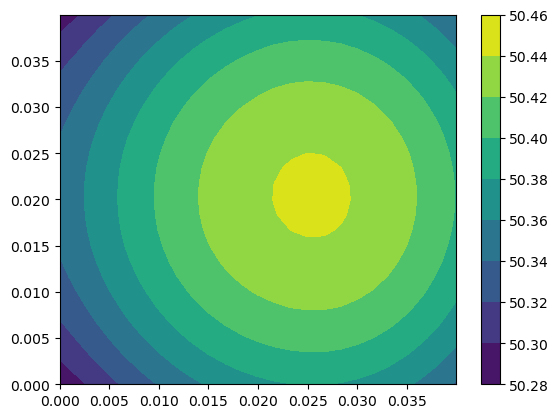

In [10]:
import matplotlib.pyplot as plt

# plotting initial conditions T0
fig, ax = plt.subplots()
contour1 = ax.contourf(heq.X, heq.Y, u_final - 273)
fig.colorbar(contour1, ax=ax)
plt.show()